In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

file_path = "sugar_consumption_dataset.csv"
df = pd.read_csv(file_path)


df.head(), df.columns.tolist()



(     Country  Year Country_Code Continent                   Region  \
 0     France  1972          FRA    Europe           Western Europe   
 1  Australia  2003          AUS   Oceania  Australia & New Zealand   
 2    Germany  1963          DEU    Europe           Western Europe   
 3     France  1965          FRA    Europe           Western Europe   
 4    Germany  2010          DEU    Europe           Western Europe   
 
      Population  GDP_Per_Capita  Per_Capita_Sugar_Consumption  \
 0  2.617306e+08     8692.631696                     12.827741   
 1  1.737965e+08     6859.195960                     21.362632   
 2  1.236366e+08    22075.950580                     32.077485   
 3  2.989961e+08     3728.027392                     47.648930   
 4  7.341531e+06    40420.973960                     23.214343   
 
    Total_Sugar_Consumption  Sugar_From_Sugarcane  ...  \
 0             3.357413e+06             68.422963  ...   
 1             3.712750e+06             55.432564  ...   


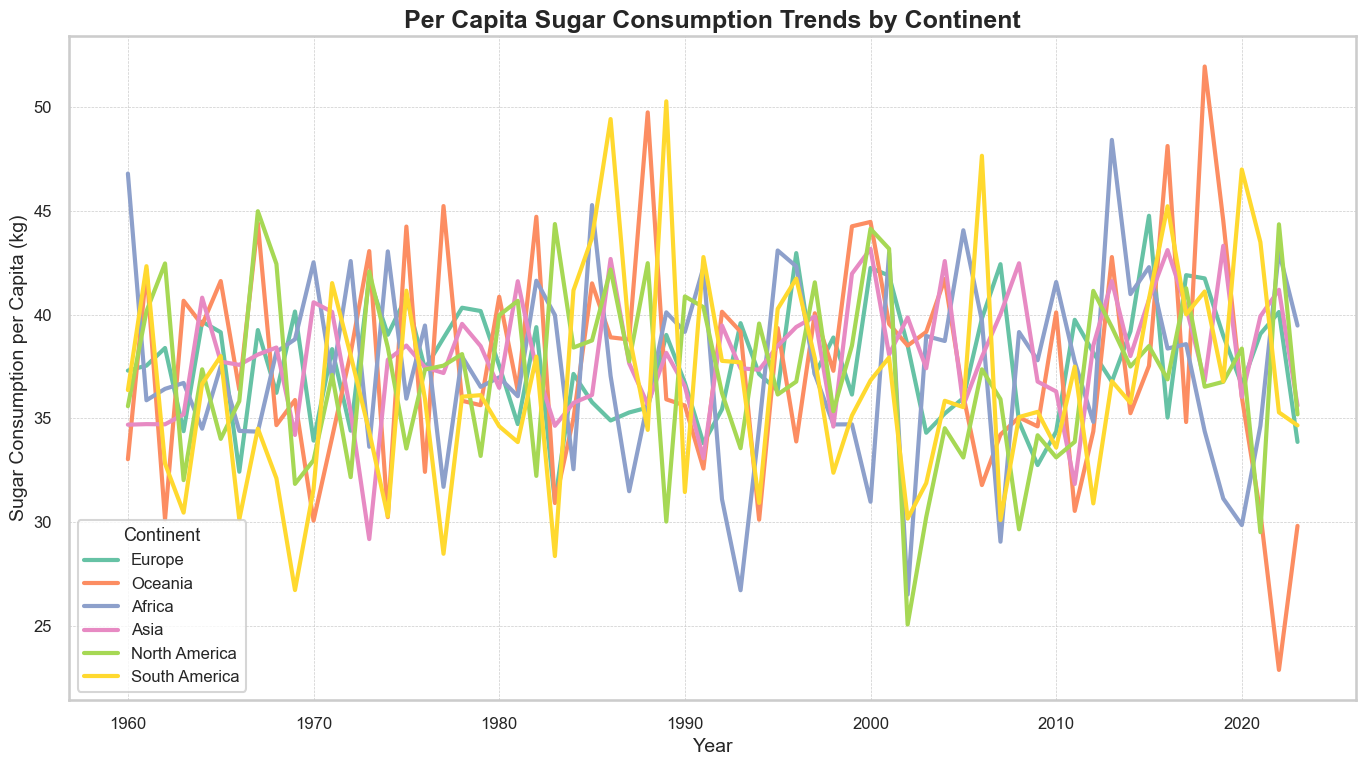

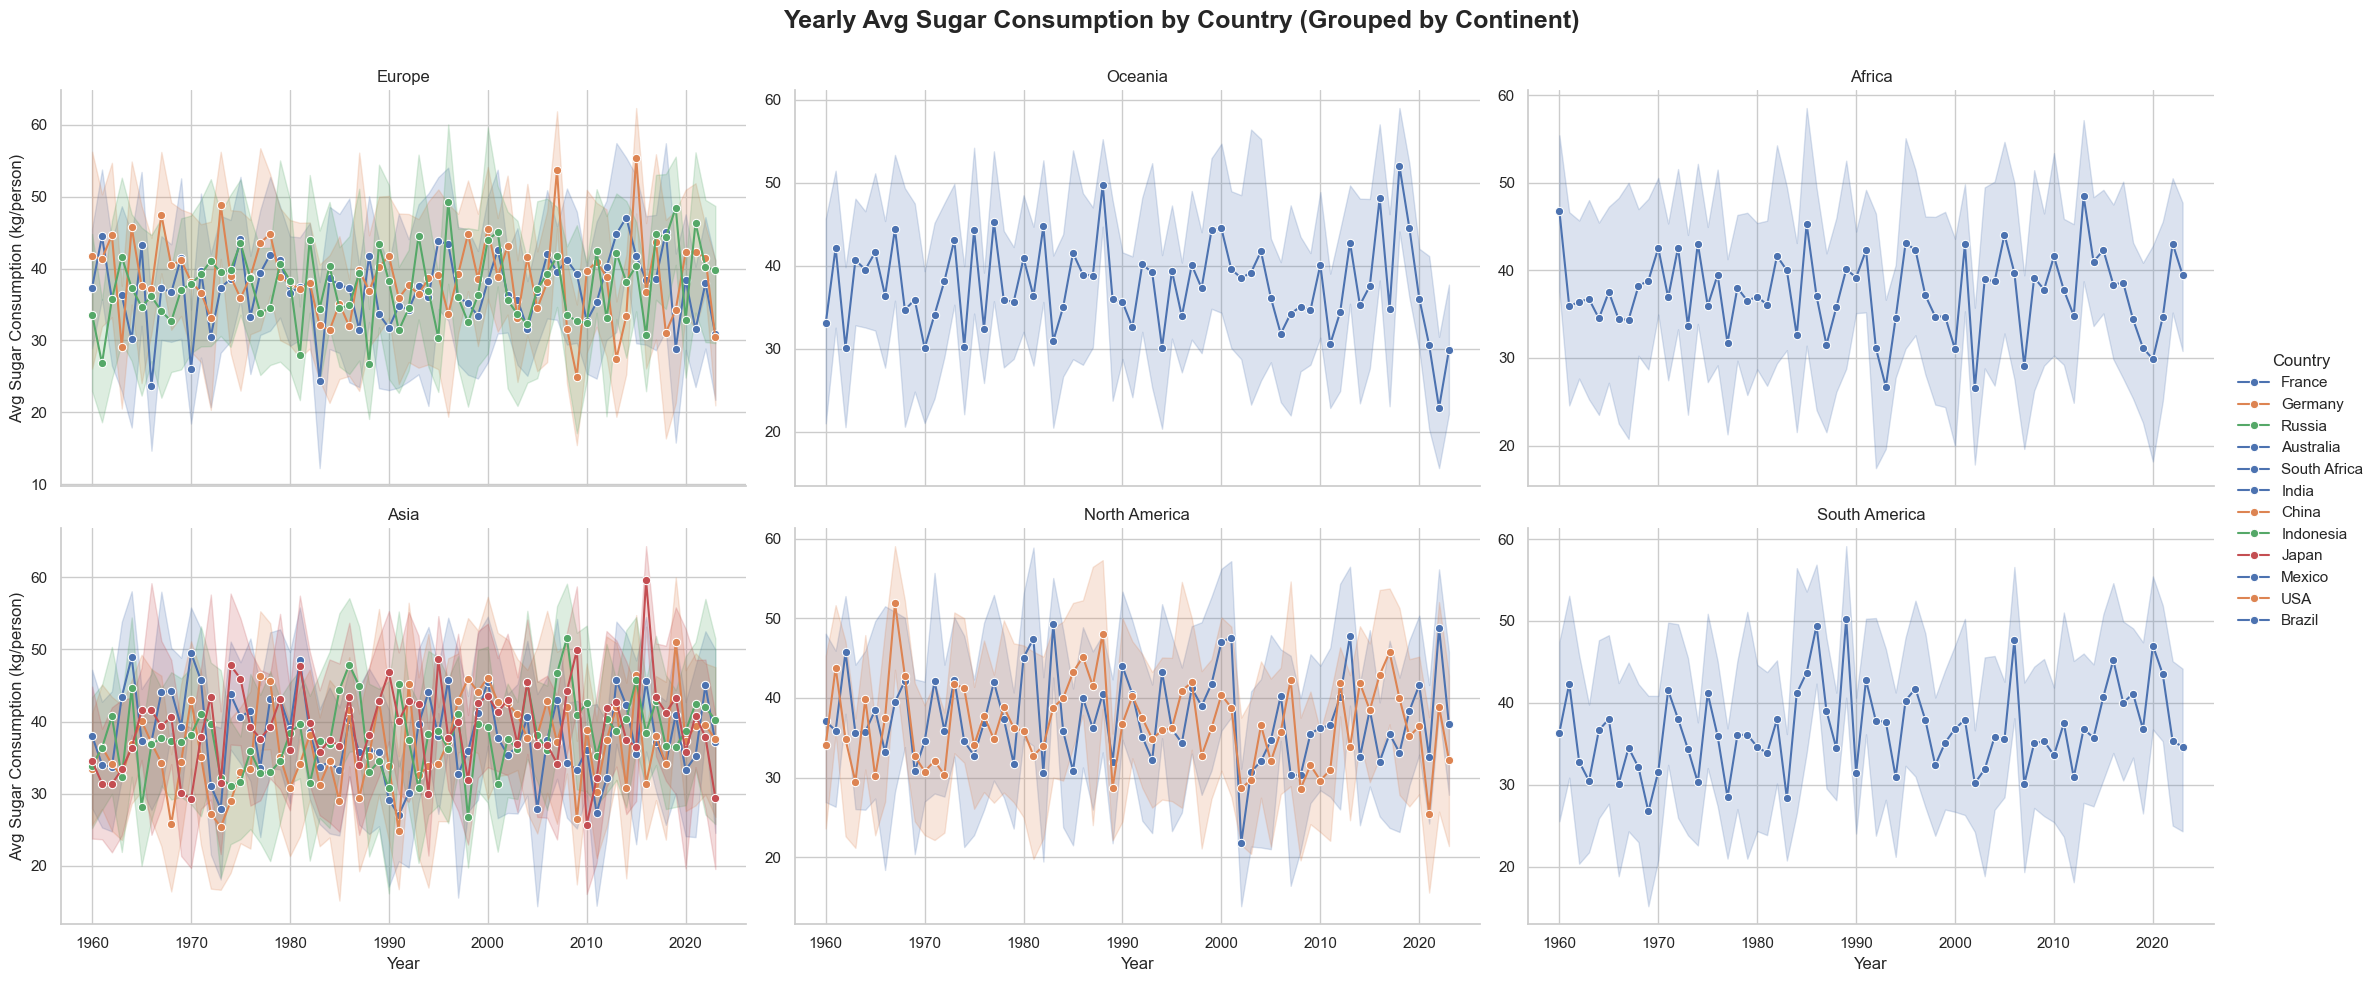

C:\Users\Manish\AppData\Local\Temp\ipykernel_7336\3703353989.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


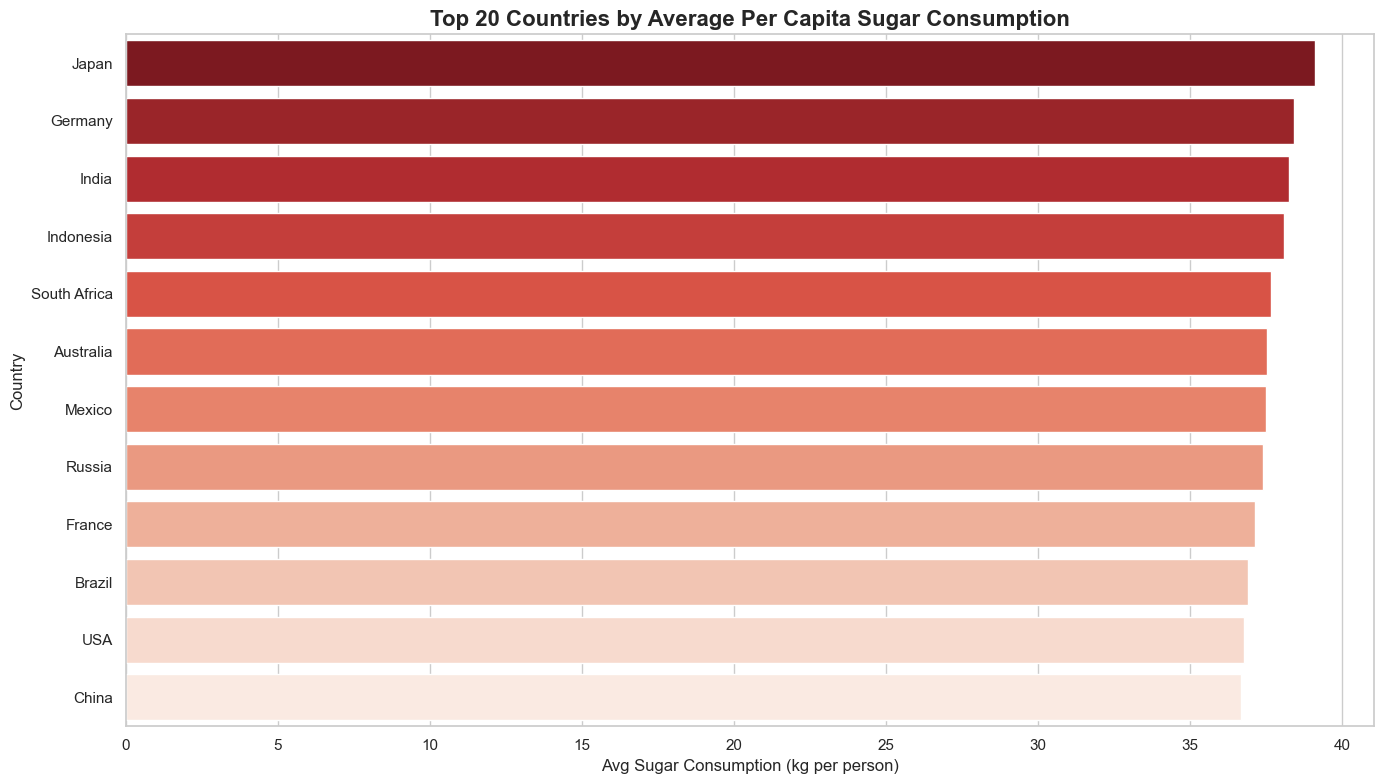

In [21]:
# Objective 1: Analyze Per Capita Sugar Consumption Trends
# Investigate how per capita sugar consumption varies across countries, continents, and over time to identify patterns or anomalies.

# Create a cleaned version of the dataframe (if needed)
df_clean = df.dropna(subset=["Per_Capita_Sugar_Consumption", "Continent", "Country", "Year"])

# For finding overall statistics of the dataset
plt.figure(figsize=(14, 8))
sns.set(style="whitegrid", context="talk")

palette = sns.color_palette("Set2", df_clean["Continent"].nunique())

sns.lineplot(
    data=df_clean,
    x="Year",
    y="Per_Capita_Sugar_Consumption",
    hue="Continent",
    estimator="mean",
    errorbar=None,
    lw=3,
    palette=palette
)

plt.title("Per Capita Sugar Consumption Trends by Continent", fontsize=18, weight='bold')
plt.xlabel("Year", fontsize=14)
plt.ylabel("Sugar Consumption per Capita (kg)", fontsize=14)
plt.legend(title="Continent", fontsize=12, title_fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# For finding the average consumption continent-wise followed by country-wise
sns.set(style="whitegrid")

continents = df_clean["Continent"].dropna().unique()

g = sns.FacetGrid(
    df_clean,
    col="Continent",
    col_wrap=3,
    height=5,
    aspect=1.5,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="Year",
    y="Per_Capita_Sugar_Consumption",
    hue="Country",
    marker="o"
)

g.set_titles("{col_name}")
g.set_axis_labels("Year", "Avg Sugar Consumption (kg/person)")
g.add_legend(title="Country")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Yearly Avg Sugar Consumption by Country (Grouped by Continent)", fontsize=18, weight='bold')

plt.show()

# For finding the top 20 countries by average per capita sugar consumption
avg_country = df_clean.groupby("Country")["Per_Capita_Sugar_Consumption"].mean().reset_index()

avg_country = avg_country.sort_values(by="Per_Capita_Sugar_Consumption", ascending=False)

plt.figure(figsize=(14, 8))
sns.set(style="whitegrid")
sns.barplot(
    data=avg_country.head(20),
    x="Per_Capita_Sugar_Consumption",
    y="Country",
    palette="Reds_r"
)

plt.title("Top 20 Countries by Average Per Capita Sugar Consumption", fontsize=16, weight='bold')
plt.xlabel("Avg Sugar Consumption (kg per person)", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()
plt.show()


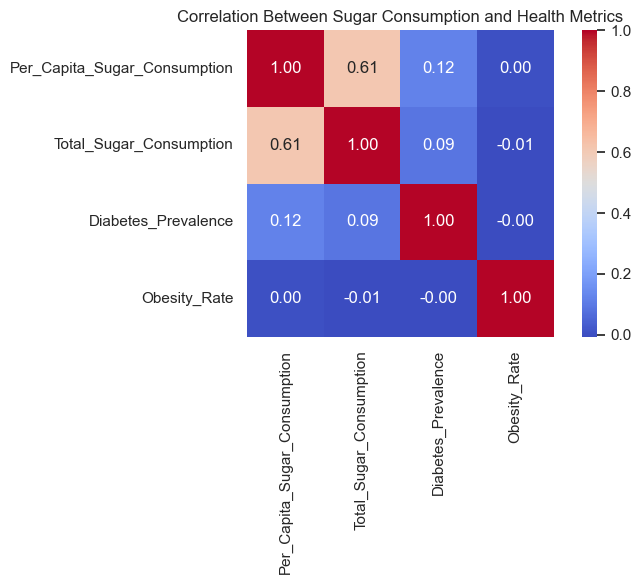

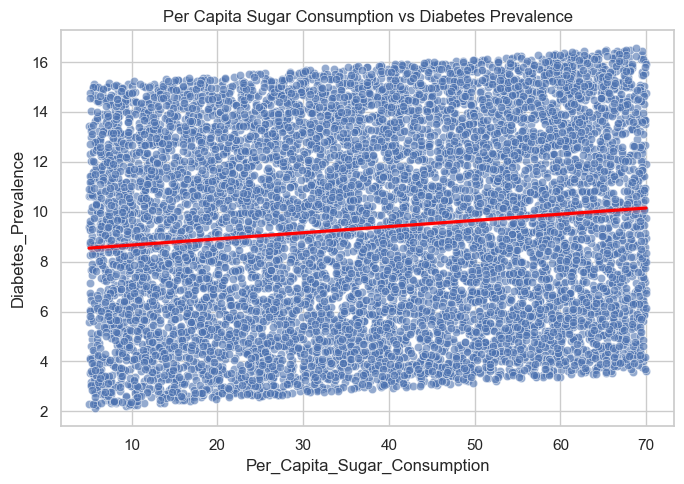

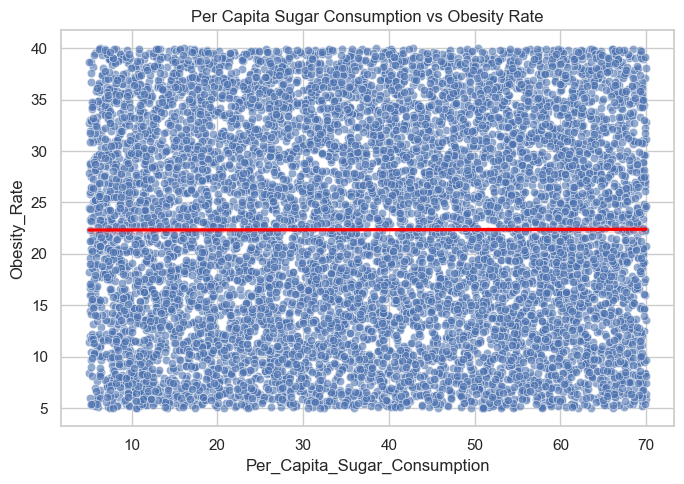

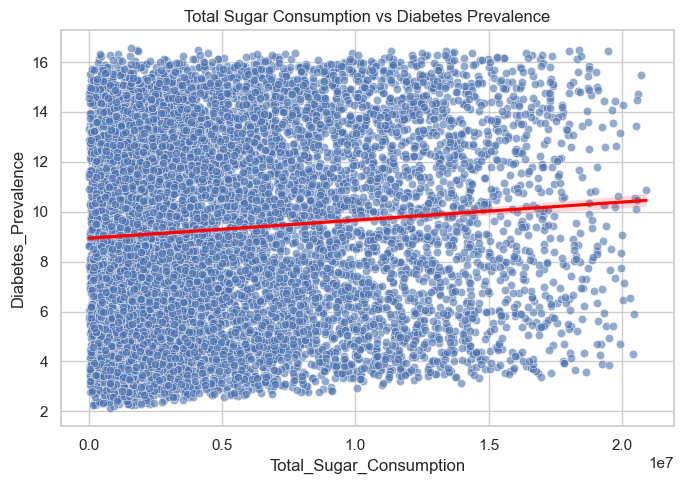

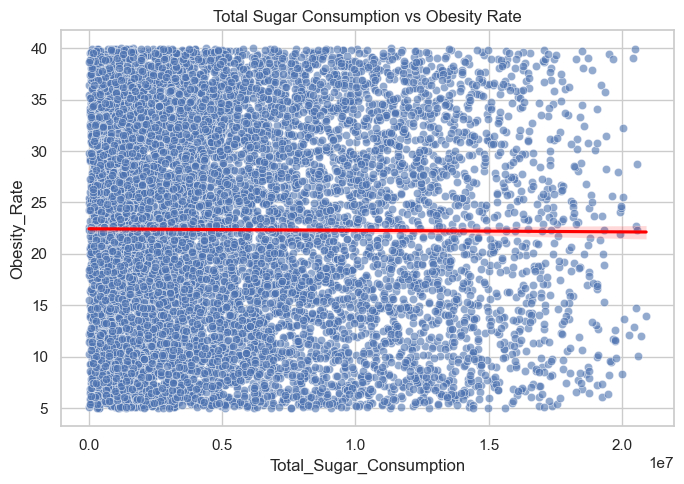

In [ ]:
#Objective 2: Explore Relationships Between Sugar Consumption and Health Metrics  -  Examine correlations between sugar consumption (per capita/total) and health indicators like diabetes prevalence and obesity rates.

cols_of_interest = [
    'Per_Capita_Sugar_Consumption',
    'Total_Sugar_Consumption',
    'Diabetes_Prevalence',
    'Obesity_Rate'
]
subset_df = df[cols_of_interest]

# 1. Correlation Matrix and Heatmap
correlation_matrix = subset_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Between Sugar Consumption and Health Metrics')
plt.tight_layout()
plt.show()

# 2. Scatter Plots to Visualize Relationships

# Scatter: Per Capita Sugar Consumption vs Diabetes Prevalence
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Per_Capita_Sugar_Consumption', y='Diabetes_Prevalence', alpha=0.6)
sns.regplot(data=df, x='Per_Capita_Sugar_Consumption', y='Diabetes_Prevalence', scatter=False, color='red')
plt.title('Per Capita Sugar Consumption vs Diabetes Prevalence')
plt.tight_layout()
plt.show()

# Scatter: Per Capita Sugar Consumption vs Obesity Rate
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Per_Capita_Sugar_Consumption', y='Obesity_Rate', alpha=0.6)
sns.regplot(data=df, x='Per_Capita_Sugar_Consumption', y='Obesity_Rate', scatter=False, color='red')
plt.title('Per Capita Sugar Consumption vs Obesity Rate')
plt.tight_layout()
plt.show()

# Scatter: Total Sugar Consumption vs Diabetes Prevalence
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Total_Sugar_Consumption', y='Diabetes_Prevalence', alpha=0.6)
sns.regplot(data=df, x='Total_Sugar_Consumption', y='Diabetes_Prevalence', scatter=False, color='red')
plt.title('Total Sugar Consumption vs Diabetes Prevalence')
plt.tight_layout()
plt.show()

# Scatter: Total Sugar Consumption vs Obesity Rate
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Total_Sugar_Consumption', y='Obesity_Rate', alpha=0.6)
sns.regplot(data=df, x='Total_Sugar_Consumption', y='Obesity_Rate', scatter=False, color='red')
plt.title('Total Sugar Consumption vs Obesity Rate')
plt.tight_layout()
plt.show()

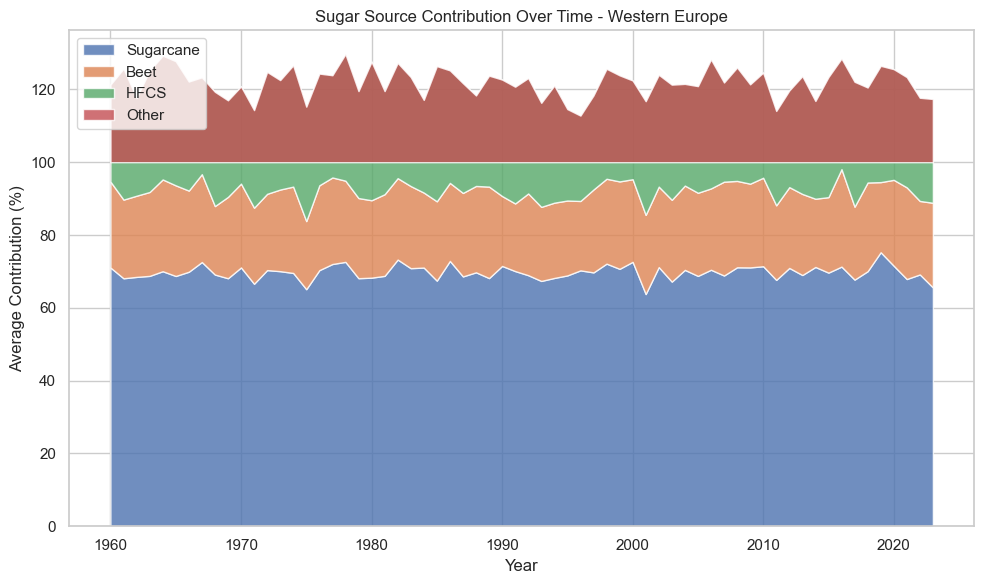

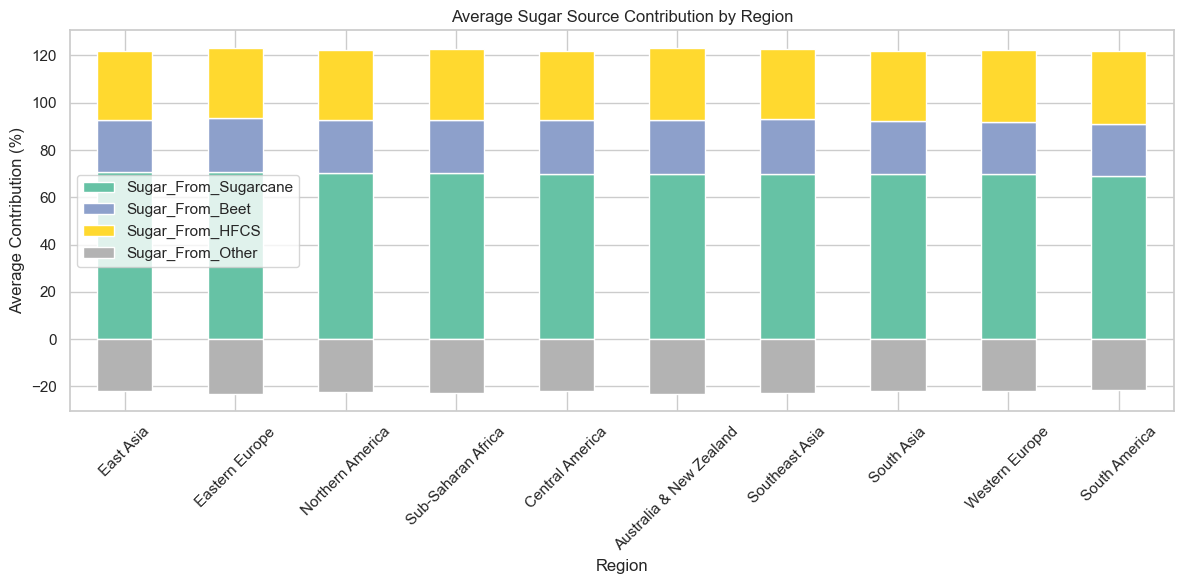

In [ ]:
# Objective 3: Compare Sugar Production Sources  -  Analyze the contribution of different sugar sources (sugarcane, beet, HFCS, etc.) by country/region and their changes over time.
sugar_sources = [
    'Sugar_From_Sugarcane',
    'Sugar_From_Beet',
    'Sugar_From_HFCS',
    'Sugar_From_Other'
]

# 1. Aggregate sugar sources by REGION and YEAR
region_year_sources = df.groupby(['Region', 'Year'])[sugar_sources].mean().reset_index()

# Plot stacked area chart for a selected region (e.g., "Western Europe")
selected_region = "Western Europe"
region_data = region_year_sources[region_year_sources['Region'] == selected_region]

plt.figure(figsize=(10, 6))
plt.stackplot(region_data['Year'],
              region_data['Sugar_From_Sugarcane'],
              region_data['Sugar_From_Beet'],
              region_data['Sugar_From_HFCS'],
              region_data['Sugar_From_Other'],
              labels=['Sugarcane', 'Beet', 'HFCS', 'Other'],
              alpha=0.8)
plt.legend(loc='upper left')
plt.title(f'Sugar Source Contribution Over Time - {selected_region}')
plt.xlabel('Year')
plt.ylabel('Average Contribution (%)')
plt.tight_layout()
plt.show()

# 2. Average sugar source contribution by REGION (bar chart)
region_avg = df.groupby('Region')[sugar_sources].mean().sort_values(by='Sugar_From_Sugarcane', ascending=False)

region_avg.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Average Sugar Source Contribution by Region')
plt.ylabel('Average Contribution (%)')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

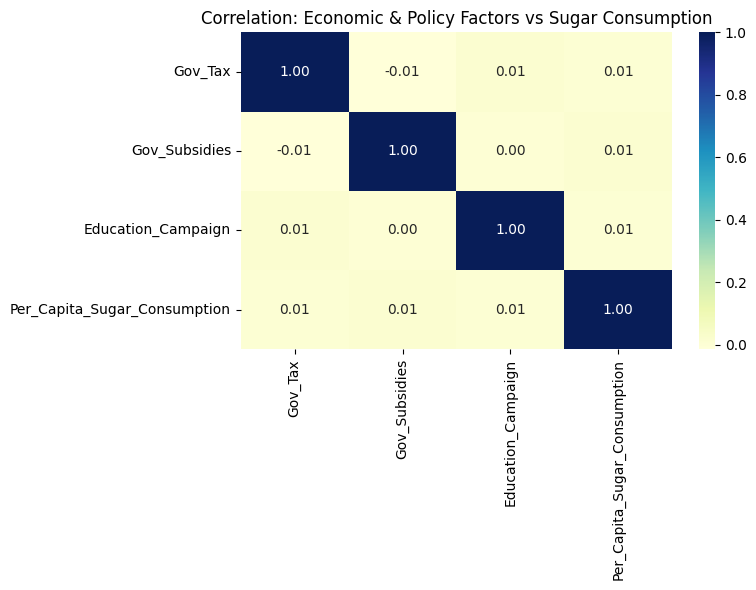

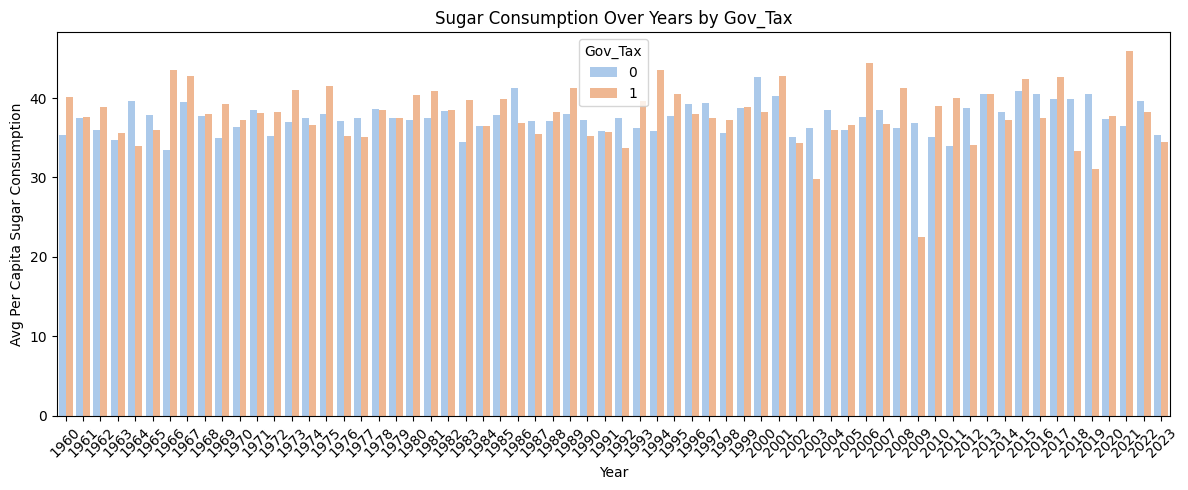

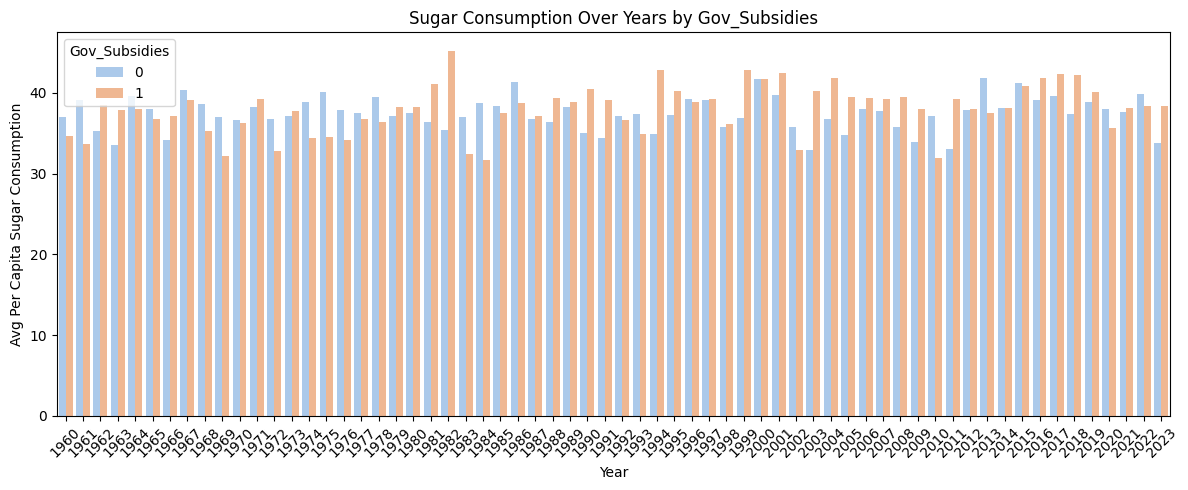

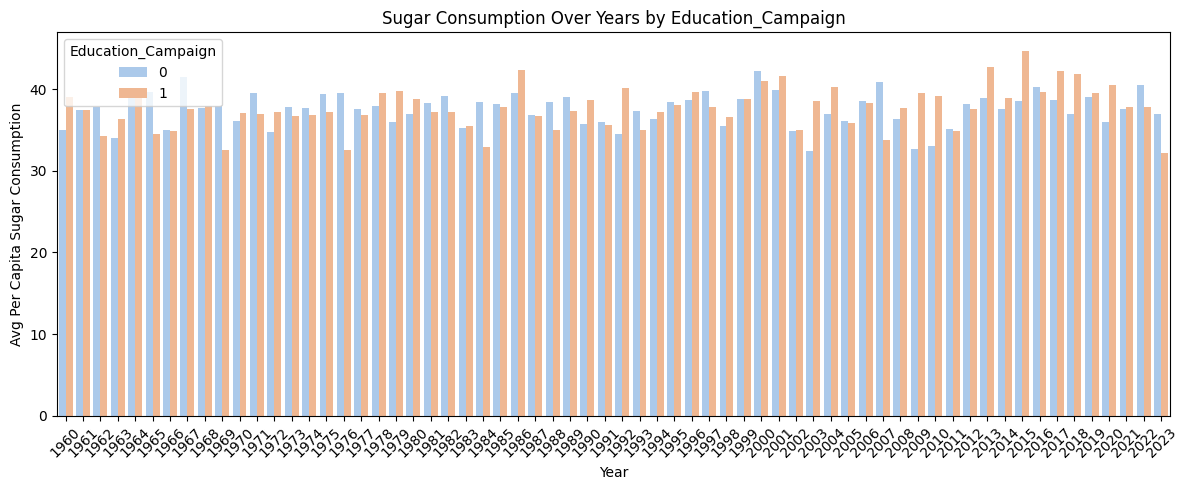

In [17]:
# Objective 4: Assess Economic and Policy Influences  -  Study how GDP per capita, government taxes/subsidies, and education campaigns impact sugar consumption trends.

cols = [
    'Gov_Tax',
    'Gov_Subsidies',
    'Education_Campaign',
    'Per_Capita_Sugar_Consumption'
]

policy_df = df[cols]

plt.figure(figsize=(8, 6))
sns.heatmap(policy_df.corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title('Correlation: Economic & Policy Factors vs Sugar Consumption')
plt.tight_layout()
plt.show()


def calc_impact(policy_column):
    plt.figure(figsize=(12, 5))

    # Grouped barplot: one group per year, color by policy (0 or 1)
    sns.barplot(
        data=df,
        x='Year',
        y='Per_Capita_Sugar_Consumption',
        hue=policy_column,
        palette='pastel',
        errorbar=None,
        estimator=np.mean
    )

    plt.title(f'Sugar Consumption Over Years by {policy_column}')
    plt.xlabel('Year')
    plt.ylabel('Avg Per Capita Sugar Consumption')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    
calc_impact('Gov_Tax')
calc_impact('Gov_Subsidies')
calc_impact('Education_Campaign')



🔼 Sharpest Increases:
            Country  Year    YoY_Change
9937  South Africa  1981  2.079291e+07
3649     Australia  1994  2.013467e+07
6670         India  2019  1.967610e+07
5930           USA  1977  1.930595e+07
2342         Japan  2000  1.920168e+07
4049         India  1976  1.918618e+07
5570         India  1967  1.916569e+07
4060         China  2014  1.909092e+07
3316     Australia  2014  1.900834e+07
920         France  1982  1.896681e+07

🔽 Sharpest Decreases:
            Country  Year    YoY_Change
3610     Australia  2014 -2.012204e+07
3656     Australia  1994 -2.010430e+07
6010         India  1967 -1.942241e+07
3740  South Africa  1965 -1.903856e+07
8954        France  2003 -1.897454e+07
4407         China  1992 -1.893824e+07
1484       Germany  1978 -1.891163e+07
5542        France  1965 -1.873586e+07
9008        Mexico  1994 -1.856850e+07
1068        France  1982 -1.848717e+07


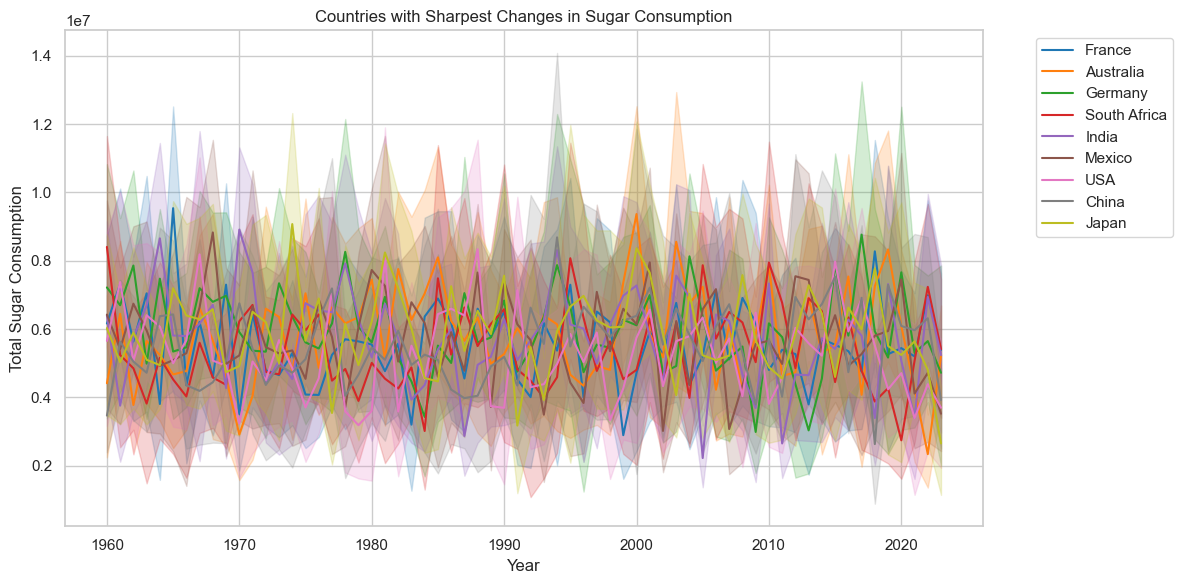

In [22]:
# Objective 5: Visualize Regional and Temporal Patterns  -  Create interactive visualizations (maps, time-series plots) to highlight regional disparities and global trends in sugar consumption.

# Sort by country and year
df_sorted = df.sort_values(by=['Country', 'Year'])

# Calculate year-over-year change in sugar consumption
df_sorted['YoY_Change'] = df_sorted.groupby('Country')['Total_Sugar_Consumption'].diff()

# Drop NaN (first year will have NaN change)
changes = df_sorted.dropna(subset=['YoY_Change'])

# Find countries with largest INCREASE
top_increases = changes.sort_values(by='YoY_Change', ascending=False).head(10)

# Find countries with largest DECREASE
top_decreases = changes.sort_values(by='YoY_Change').head(10)

print("🔼 Sharpest Increases:\n", top_increases[['Country', 'Year', 'YoY_Change']])
print("\n🔽 Sharpest Decreases:\n", top_decreases[['Country', 'Year', 'YoY_Change']])


# Combine top increasing and decreasing countries
highlight_countries = pd.concat([top_increases['Country'], top_decreases['Country']]).unique()

highlight_df = df[df['Country'].isin(highlight_countries)]

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=highlight_df,
    x='Year',
    y='Total_Sugar_Consumption',
    hue='Country',
    palette='tab10'
)

plt.title('Countries with Sharpest Changes in Sugar Consumption')
plt.xlabel('Year')
plt.ylabel('Total Sugar Consumption')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
